Checking the sum of final scores for Pearson : 100
Checking the of final scores for Spearman: 100
Checking the of final scores for Kendall: 100
Checking the of final scores for MI: 100
Checking the of final scores for dCor: 100
Checking the of final scores for HSIC: 100


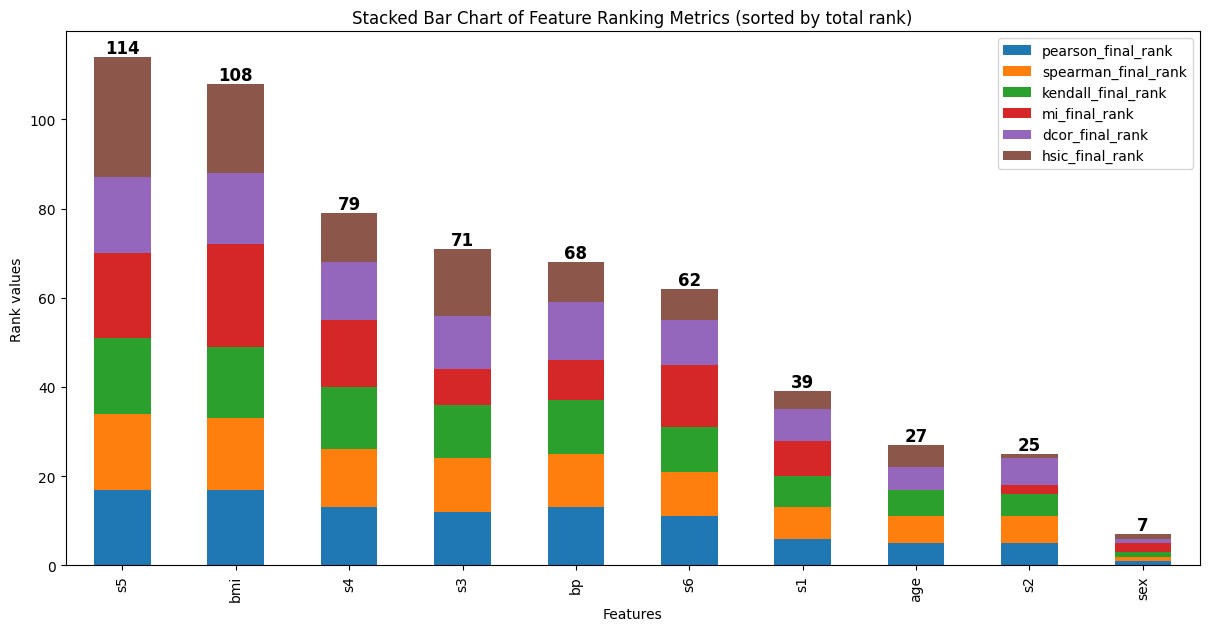

In [5]:
from sklearn.feature_selection import mutual_info_regression
from scipy.stats import spearmanr, pearsonr, kendalltau
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_diabetes
from hyppo.independence import Hsic
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def distance_correlation(x, y): # ref Székely et al., 2007

    x = np.asarray(x, dtype=float).reshape(-1, 1)
    y = np.asarray(y, dtype=float).reshape(-1, 1)

    mask = np.isfinite(x[:, 0]) & np.isfinite(y[:, 0])
    x = x[mask]
    y = y[mask]

    n = x.shape[0]
    if n < 2:
        return np.nan

    a = np.abs(x - x.T) # matrixes |xi - xj|
    b = np.abs(y - y.T)
    
    A = a - a.mean(axis=0, keepdims=True) - a.mean(axis=1, keepdims=True) + a.mean() #centering procedure
    B = b - b.mean(axis=0, keepdims=True) - b.mean(axis=1, keepdims=True) + b.mean()
    
    dcov2 = (A * B).sum() / (n * n) #  cov2 and var2 caclulation
    dvarx2 = (A * A).sum() / (n * n)
    dvary2 = (B * B).sum() / (n * n)

    if dvarx2 <= 0 or dvary2 <= 0:
        return 0.0

    dcor = np.sqrt(dcov2) / np.sqrt(np.sqrt(dvarx2) * np.sqrt(dvary2))
    return float(np.clip(dcor, 0.0, 1.0))


def proportional_ranks(score_series, total_points=100): #function for converting in scores
    score_series = score_series.copy()

    if np.all(~np.isfinite(score_series)) or score_series.sum() == 0:
        return pd.Series(0, index=score_series.index, dtype=int)

    score_series = score_series.fillna(0)
    sum_scores = score_series.sum()
    raw_ranks = total_points * score_series / sum_scores
    int_ranks = np.floor(raw_ranks).astype(int) #rounding
    remainder = raw_ranks - int_ranks
    missing = total_points - int_ranks.sum() # add missing scores
    if missing > 0:
        add_indices = remainder.nlargest(missing).index
        int_ranks.loc[add_indices] += 1

    return int_ranks  


def compute_hsic_series(X, y): #HSIC statistic

    tester = Hsic()
    y_arr = np.asarray(y, dtype=float).reshape(-1, 1)

    hsic_vals = []
    for j in range(X.shape[1]):
        x_arr = np.asarray(X.iloc[:, j].values, dtype=float).reshape(-1, 1)

        # Маска без NaN
        mask = np.isfinite(x_arr[:, 0]) & np.isfinite(y_arr[:, 0])
        x_clean = x_arr[mask]
        y_clean = y_arr[mask]

        if x_clean.shape[0] < 2:
            hsic_vals.append(np.nan)
            continue

        stat = tester.statistic(x_clean, y_clean)
        hsic_vals.append(stat)

    hsic_series = pd.Series(hsic_vals, index=X.columns)
    hsic_series = hsic_series.clip(lower=0) #make values >= 0

    return hsic_series


def filter_ranking_regression(X, y, total_points=171, mi_random_state=0):
    n_samples, n_features = X.shape
    scores = {}

    scores["pearson_abs"] = np.array([abs(pearsonr(X.iloc[:, j], y)[0]) for j in range(n_features) ]) #Pearson absolute values, filter №1
    scores["spearman_abs"] = np.array([abs(spearmanr(X.iloc[:, j], y)[0]) for j in range(n_features) ]) # Spearman absolute values, filter №2
    scores["kendall_abs"] = np.array([abs(kendalltau(X.iloc[:, j], y)[0])  for j in range(n_features) ]) #absolute absolute values, filter №3
    scores["mi"] = mutual_info_regression(X, y, random_state=mi_random_state) # Mutual-based values, filter №4
    y_arr = np.asarray(y).ravel()
    scores["dcor"] = np.array([distance_correlation(X.iloc[:, j].values, y_arr) for j in range(n_features)]) #Distance Correlation based values, filter №5
    scores["hsic"] = compute_hsic_series(X, y).values # HSIC values, filter №6

    df = pd.DataFrame(scores, index=X.columns)
    
    pearson_points = proportional_ranks(df["pearson_abs"], total_points=total_points) # proportional scores for each feature
    spearman_points = proportional_ranks(df["spearman_abs"], total_points=total_points)
    kendall_points = proportional_ranks(df["kendall_abs"], total_points=total_points)
    mi_points = proportional_ranks(df["mi"], total_points=total_points)
    dcor_points = proportional_ranks(df["dcor"], total_points=total_points)
    hsic_points = proportional_ranks(df["hsic"], total_points=total_points)

    df["pearson_final_rank"] = pearson_points.astype(int) #adding in dataframe
    df["spearman_final_rank"] = spearman_points.astype(int)
    df["kendall_final_rank"] = kendall_points.astype(int)
    df["mi_final_rank"] = mi_points.astype(int)
    df["dcor_final_rank"] = dcor_points.astype(int)
    df["hsic_final_rank"] = hsic_points.astype(int)

    r = df[["pearson_abs", "spearman_abs", "kendall_abs", "mi", "dcor", "hsic"]].rank(ascending=True) #add statistics
    nr = (r - 1) / (n_features - 1)
    nr["avg_norm_rank"] = nr.mean(axis=1) # normalizating ranks in [0; 1]

    result = pd.concat([df, r.add_suffix("_rank"), nr.add_suffix("_norm"),], axis=1).sort_values("avg_norm_rank_norm", ascending=True)#

    print("Checking the sum of final scores for Pearson :",  result["pearson_final_rank"].sum()) # output of the results checking
    print("Checking the of final scores for Spearman:", result["spearman_final_rank"].sum())
    print("Checking the of final scores for Kendall:",  result["kendall_final_rank"].sum())
    print("Checking the of final scores for MI:",       result["mi_final_rank"].sum())
    print("Checking the of final scores for dCor:",     result["dcor_final_rank"].sum())
    print("Checking the of final scores for HSIC:",     result["hsic_final_rank"].sum())

    return result

####################################################
###########Usage on a diabetes dataset##############
####################################################

data = load_diabetes()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

features_result = filter_ranking_regression(X_scaled, y.values.ravel(), total_points=100, mi_random_state=0)

stacked_data = features_result[['pearson_final_rank','spearman_final_rank', 'kendall_final_rank','mi_final_rank', 'dcor_final_rank', 'hsic_final_rank']]

stacked_data_sorted = stacked_data.copy() #caclulating the sum of ranks
stacked_data_sorted["total_rank"] = stacked_data.sum(axis=1)

stacked_data_sorted = stacked_data_sorted.sort_values("total_rank", ascending=False) # sorting from top to low total ranks
stacked_data_sorted = stacked_data_sorted.drop(columns=["total_rank"])

ax = stacked_data_sorted.plot(kind="bar",stacked=True,figsize=(12, 6))

totals = stacked_data_sorted.sum(axis=1)

for i, total in enumerate(totals):
    ax.text(i, total, int(total), ha="center", va="bottom", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.xlabel("Features")
plt.ylabel("Rank values")
plt.title("Stacked Bar Chart of Feature Ranking Metrics (sorted by total rank)")
plt.show()

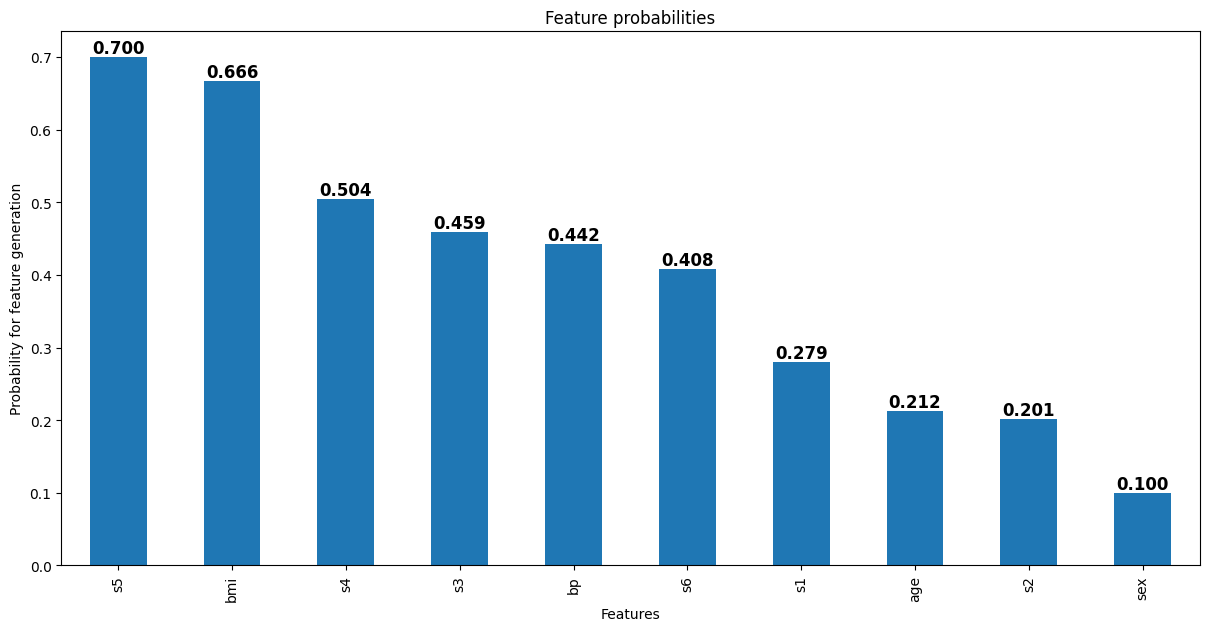

In [6]:
vals = stacked_data_sorted.sum(axis=1)
old_min = vals.min()
old_max = vals.max()
new_min = 0.1
new_max = 0.7
normalized_prob = new_min + (vals - old_min) * (new_max - new_min) / (old_max - old_min)

ax = normalized_prob.plot(kind="bar", figsize=(12, 6))

for i, v in enumerate(normalized_prob):
    ax.text( i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.xlabel("Features")
plt.ylabel("Probability for feature generation")
plt.title("Feature probabilities")
plt.show()

array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'bmi'}>],
       [<Axes: title={'center': 'bp'}>, <Axes: title={'center': 's1'}>,
        <Axes: title={'center': 's2'}>],
       [<Axes: title={'center': 's3'}>, <Axes: title={'center': 's4'}>,
        <Axes: title={'center': 's5'}>],
       [<Axes: title={'center': 's6'}>, <Axes: >, <Axes: >]], dtype=object)

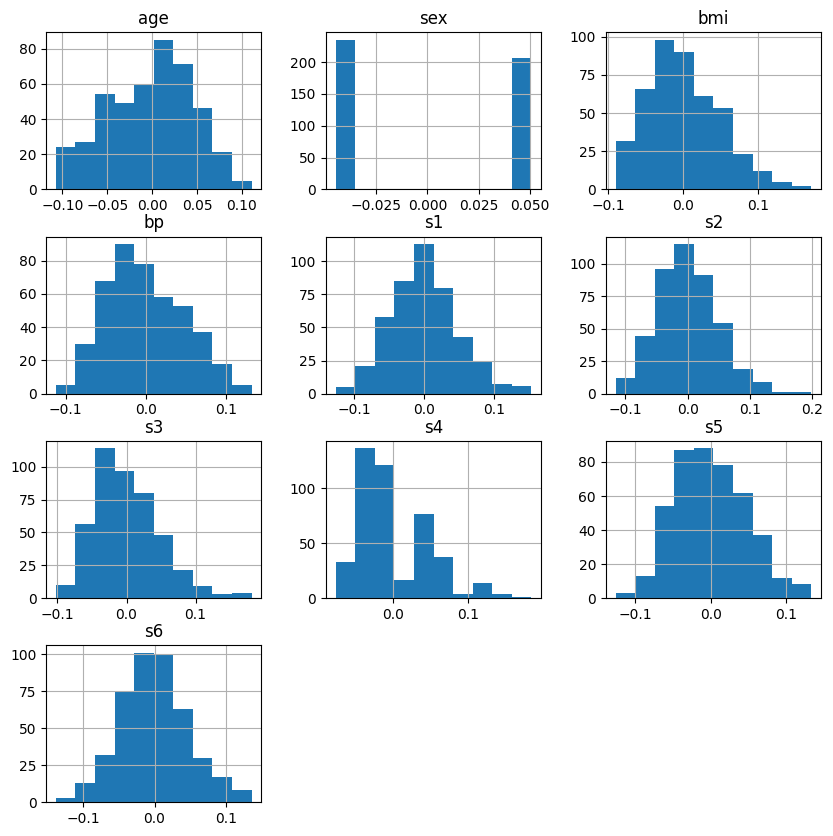

In [10]:
pd.DataFrame(X).hist(figsize = (10, 10))

array([[<Axes: title={'center': 'target'}>]], dtype=object)

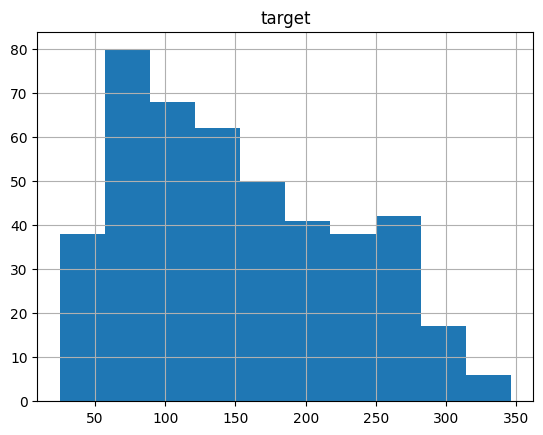

In [13]:
pd.DataFrame(y).hist()